In [28]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import ipywidgets as widgets
from IPython.display import display, clear_output

folder_names = ["highway", "pedestrian", "office"]

def load_folder_name(folder_name: str) -> tuple[list[np.ndarray], list[np.ndarray], np.ndarray]:
    """Return grayscale frames, ground truth masks, and ROI mask."""
    roi = cv2.imread(f"{folder_name}/ROI.jpg")
    roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    roi = roi > 0

    with open(f"{folder_name}/temporalROI.txt", "r") as f:
        line = f.readline()
        a, b = map(int, line.split(" "))

    imgs = [None] * (b - a + 1)
    gts = [None] * (b - a + 1)
    for i in range(a, b + 1):
        path = str(i).zfill(6)
        gt = folder_name + "/groundtruth/" + "gt" + path + ".png"
        img = folder_name + "/input/" + "in" + path + ".jpg"
        gt_img = cv2.imread(gt)
        gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2GRAY) if gt_img is not None else None
        img_data = cv2.imread(img)
        img_data = cv2.cvtColor(img_data, cv2.COLOR_BGR2GRAY) if img_data is not None else None

        if gt_img is not None and img_data is not None:
            gts[i - a] = gt_img
            imgs[i - a] = img_data
        else:
            print(f"i={i}, Błąd przy wczytywaniu")
    print(len(imgs))
    print(len(gts))
    print(b-a+1)
    return imgs, gts, roi,0,b-a

def calculate_diffs(imgs: list[np.ndarray], gts: list[np.ndarray], roi: np.ndarray) -> list[np.ndarray]:
    """Compute motion masks from consecutive frames."""
    diffs = [None] * (len(gts)-1)
    
    for i in range(0, len(gts)-1 ):
        
        im = np.abs(imgs[i + 1].astype("int16") - imgs[i].astype("int16")).astype("uint8")
        _, thresh = cv2.threshold(im, 13, 255, cv2.THRESH_BINARY)
        thresh = (thresh & roi * 255).astype("uint8")
        
        im_org = thresh
        im = cv2.medianBlur(im_org, 3)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        im = cv2.morphologyEx(im, cv2.MORPH_ERODE, kernel)
        im = cv2.morphologyEx(im, cv2.MORPH_ERODE,(3,3))
        while True:
            im2 = cv2.morphologyEx(im, cv2.MORPH_DILATE, kernel)
            im3 = im2 & im_org
            if (im3 == im).all():
                break
            im = im3
        im = cv2.morphologyEx(im, cv2.MORPH_DILATE, (3,3))
        im = cv2.morphologyEx(im, cv2.MORPH_DILATE, (3,3))
        kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 1))
     
        im = cv2.morphologyEx(im, cv2.MORPH_CLOSE, kernel_h)

        
        
      
        
        diffs[i] = im

    return diffs
def calculate_diffs_without_morph(imgs: list[np.ndarray], gts: list[np.ndarray], roi: np.ndarray) -> list[np.ndarray]:
    """Compute motion masks from consecutive frames."""
    diffs = [None] * (len(gts)-1)
    
    for i in range(0, len(gts)-1 ):
        
        im = np.abs(imgs[i + 1].astype("int16") - imgs[i].astype("int16")).astype("uint8")
        _, thresh = cv2.threshold(im, 10, 255, cv2.THRESH_BINARY)
        thresh = (thresh & roi * 255).astype("uint8")
        
     
        
      
        
        diffs[i] = thresh

    return diffs
def play_frames(
    imgs: list[np.ndarray],
    gts: list[np.ndarray],
    diffs: list[np.ndarray],
) -> None:
    """Simple OpenCV player. Close the window (or press q / Esc) to stop."""
    max_idx = min(len(imgs) - 1, len(gts) - 1, len(diffs) - 1)
    if max_idx < 0:
        raise ValueError("Empty input arrays.")
    interval_ms = 100
    start = 50
    step = 2
    i = start
    window_name = "Frames"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    print("getting labels")
    labels = get_labels(diffs)
    


       
    while True:
        if i > max_idx:
            i = start
        
      


        frame = cv2.hconcat([gts[i].astype(np.uint8), diffs[i].astype(np.uint8), labels[i]])
        cv2.imshow(window_name, frame)

        if cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) < 1:
            break

        key = cv2.waitKey(interval_ms) & 0xFF
        if key == ord("q") or key == 27:
            break

        i += step

    cv2.destroyWindow(window_name)

def connected_components(diffs: list[np.ndarray], idx: int = 300, l_=False, display = True,fill=False):
    idx = max(0, min(idx, len(diffs) - 1))
    retval, labels, stats, centroids = cv2.connectedComponentsWithStats(diffs[idx])
    if not display:
        return 
    print("Number of labels:", retval)
    print("Stats shape:", stats.shape)
    print("Centroids shape:", centroids.shape)
    I_VIS = diffs[idx] # copy of the input image
    if not l_ &( stats . shape [0] > 1) : # are there any objects
        for pi in range(1, stats.shape[0]):   # component ids
            x, y, w, h, area = stats[pi]
            cv2.rectangle(labels, (x, y), (x + w, y + h), int(pi), 1 if not fill else -1)  # color = label id
        tab = stats [1: ,4] # 4 columns without first element
        pi = np . argmax ( tab )+1
        print(f"pole najwiekszego prostokąta to {stats[pi,2]*stats[pi,3]}")
            # print information about the field and the number of the largest element
    if fill==True:
        return labels

    plt.figure(figsize=(8, 6))
    plt.title(f"Labels (frame {idx})")
 
    plt.imshow(labels, cmap="nipy_spectral")
    plt.axis("off")
    plt.show()
    plt.close()
def get_labels(diffs: list[np.ndarray]):
    labels_ = []
    for idx in range(0,len(diffs)):
        retval, labels, stats, centroids = cv2.connectedComponentsWithStats(diffs[idx])
        labels = cv2.normalize(labels, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        labels_.append(labels)

    return labels_

 

def scoring(diffs,gts,a,b):
    gts = np.array(gts)
    diffs = np.array(diffs)
    print(gts.shape)
    print(diffs.shape)

   
    p = 0
    r = 0
    f1 = 0
    gts = (gts>0)
    diffs=(diffs>0)
    for i in range(a, b):
        gt = (gts[i] > 0)
        pred = (diffs[i] > 0)

        tp = np.sum(gt & pred)
        fp = np.sum(~gt & pred)
        fn = np.sum(gt & ~pred)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        F1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        p += precision
        r += recall
        f1 += F1
    count = b - a
    p /= count
    r /= count
    f1 /= count
    print(f"scoring precision {p}, recall {r}, f1 {f1}")


In [29]:
# for folder_name in folder_names:
folder_name = "highway"
imgs, gts, roi,a,b= load_folder_name(folder_name)

1231
1231
1231


In [30]:

diffs_without_morph = calculate_diffs_without_morph(imgs, gts, roi)
diffs = calculate_diffs(imgs, gts, roi)


# connected_components(gts, idx=300)


In [31]:
print("calculated diffs")
player = play_frames(imgs, gts, diffs)

calculated diffs
getting labels


In [32]:
scoring(diffs,gts,a,b)

(1231, 240, 320)
(1230, 240, 320)
scoring precision 0.8553104348357758, recall 0.7036894510638029, f1 0.7680494046924037


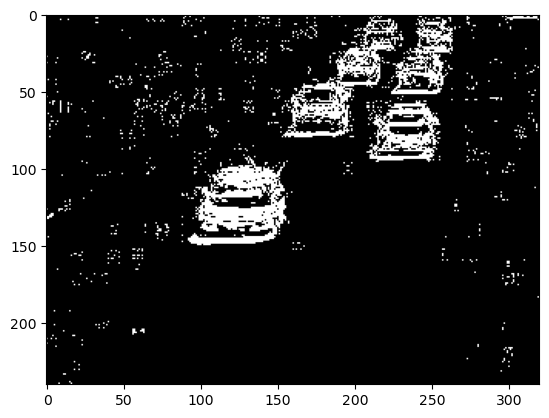

In [33]:
plt.imshow(diffs_without_morph[300],cmap="gray")

Number of labels: 5
Stats shape: (5, 5)
Centroids shape: (5, 2)


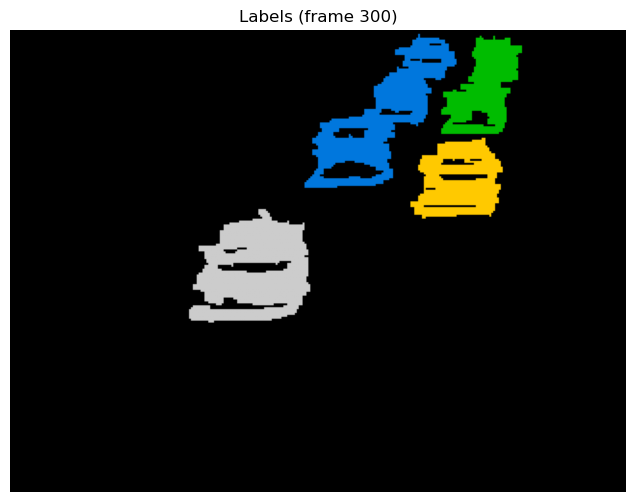

In [34]:
connected_components(diffs, idx=300,l_=True)

Number of labels: 6
Stats shape: (6, 5)
Centroids shape: (6, 2)
pole najwiekszego prostokąta to 3162


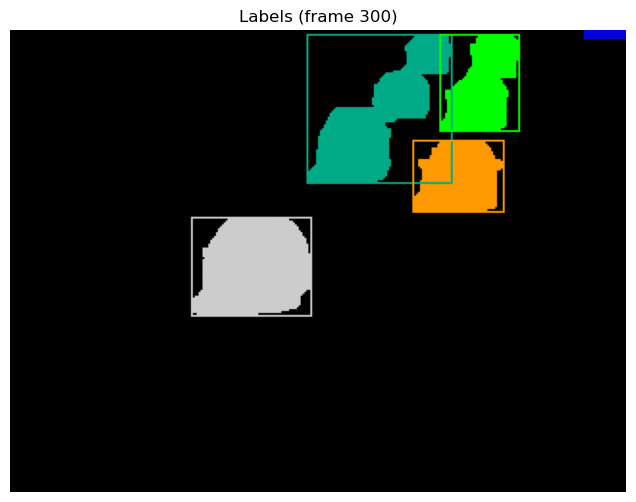

Number of labels: 5
Stats shape: (5, 5)
Centroids shape: (5, 2)
pole najwiekszego prostokąta to 3717


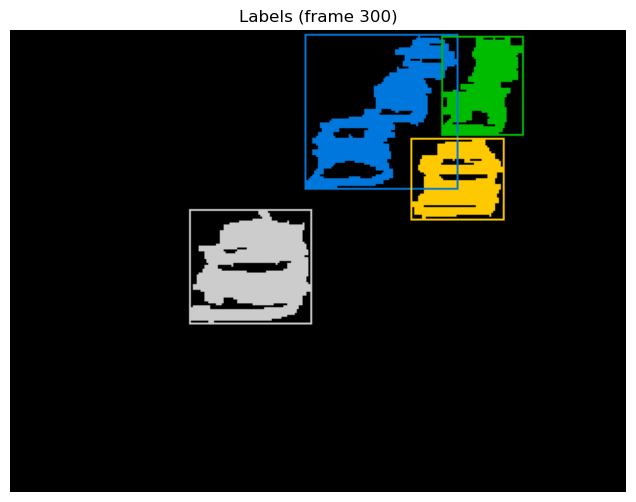

In [35]:

gts_filled = connected_components(gts, idx=300)
diffs_filled = connected_components(diffs, idx=300)

Number of labels: 6
Stats shape: (6, 5)
Centroids shape: (6, 2)
pole najwiekszego prostokąta to 3162
Number of labels: 5
Stats shape: (5, 5)
Centroids shape: (5, 2)
pole najwiekszego prostokąta to 3717


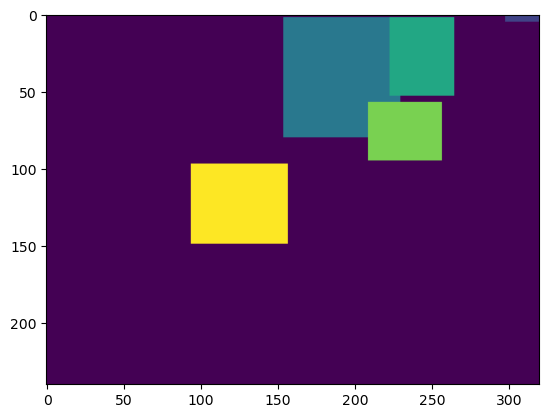

In [36]:

gts_filled = connected_components(gts, idx=300,fill=True)
diffs_filled = connected_components(diffs, idx=300,fill=True)
plt.imshow(gts_filled)